# 真實 TCCIP GRID：GP Kernel、Variogram、Buffered SKCV 與 SKCV-RLO

本 notebook 是真實 GRID 空間驗證的**正式整合版本**。分析單位是 1,412 個真實
TCCIP GRID 位置及其神經網路估計的 GEV 參數：

$$
\hat\mu,\quad \log\hat\sigma,\quad \hat\xi .
$$

方法分工：

- **Valavi et al. (2019)**：以 variogram effective range 提供候選空間分隔尺度，
  並在建模後檢查 out-of-fold residual spatial autocorrelation。
- **Pohjankukka et al.**：對每個 test fold 建立半徑 \(r_\delta\) 的 dead zone，
  並以 SKCV-RLO 隨機刪除相同數量訓練資料，分離「空間鄰近性」與「樣本量減少」的影響。

本 notebook 會直接顯示並另存：

1. AIC/BIC kernel 比較；
2. K=2--12 fold selection 與 K=5 地圖；
3. 三個 GEV 參數的 fitted variogram 與 effective range；
4. dead-zone 範例圖；
5. SKCV vs SKCV-RLO 的 RMSE--distance 核心圖；
6. training retention、四種 CV 方法比較與 fold 穩定性；
7. out-of-fold residual map、residual variogram 與 Moran's I。

> 注意：buffer distance 不是用最低 RMSE 選擇。報告距離由 effective range、實際預測距離、
> training retention 與 fold 穩定性共同解釋。

In [1]:
from pathlib import Path
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from pyproj import Transformer
from scipy.optimize import curve_fit
from scipy.sparse import csr_matrix
from scipy.spatial.distance import pdist
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    RBF,
    WhiteKernel,
)
from sklearn.metrics import mean_absolute_error, silhouette_score
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

RANDOM_STATE = 111
MAX_BASE_TRAIN = 800
MIN_TRAIN = 100
SELECTED_K = 5
RLO_REPEATS = 5
MORAN_PERMUTATIONS = 999

cwd = Path.cwd().resolve()
if (cwd / "data" / "processed").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "processed").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Run this notebook from the repository root or notebooks/.")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "grid_station_gev_params_with_loc.csv"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = {
    "mu": "mu_hat",
    "log_sigma": "log_sigma_hat",
    "xi": "xi_hat",
}
TARGET_LABELS = {
    "mu": r"$\hat{\mu}$",
    "log_sigma": r"$\log\hat{\sigma}$",
    "xi": r"$\hat{\xi}$",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("RLO repeats:", RLO_REPEATS)

PROJECT_ROOT: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\experiments\window_data
DATA_PATH: C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\experiments\window_data\data\processed\grid_station_gev_params_with_loc.csv
RLO repeats: 5


## 1. 載入真實 GRID 並將距離轉成公里

Buffer 與 variogram 不能直接把標準化經緯度當成公里。本研究將 EPSG:4326 經緯度轉為
**TWD97 / TM2 zone 121（EPSG:3826）**，並以投影座標的 Euclidean distance 計算公里距離。

In [2]:
df = pd.read_csv(DATA_PATH)
required = {"station", "lon", "lat", *TARGETS.values()}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

df = (
    df.dropna(subset=["lon", "lat", *TARGETS.values()])
      .drop_duplicates(subset=["station"])
      .reset_index(drop=True)
)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3826", always_xy=True)
x_m, y_m = transformer.transform(df["lon"].to_numpy(), df["lat"].to_numpy())
df["x_km"] = np.asarray(x_m) / 1000.0
df["y_km"] = np.asarray(y_m) / 1000.0

print(f"有效 GRID 數：{len(df):,}")
display(
    df[["station", "lon", "lat", "x_km", "y_km", *TARGETS.values()]]
    .head()
)
display(
    df[[*TARGETS.values(), "lon", "lat"]]
    .describe()
    .T[["count", "mean", "std", "min", "max"]]
)

有效 GRID 數：1,412


,station,lon,lat,x_km,y_km,mu_hat,log_sigma_hat,xi_hat
0,G119.45_23.20,119.45,23.20,91.327582,2567.275631,31.698334,-1.434958,0.227292
1,G119.50_23.35,119.50,23.35,96.618787,2583.836402,31.679490,-1.273440,0.180436
2,G119.50_23.40,119.50,23.40,96.676324,2589.374622,31.653676,-1.294992,0.181252
3,G119.50_23.50,119.50,23.50,96.791750,2600.451161,31.540771,-1.587916,0.236057
4,G119.50_23.60,119.50,23.60,96.907640,2611.527831,31.527162,-1.154317,0.129411


,count,mean,std,min,max
mu_hat,1412.0,29.246515,4.131927,16.399114,33.948245
log_sigma_hat,1412.0,-1.057337,0.366968,-2.401417,0.072698
xi_hat,1412.0,0.129251,0.116656,-0.360854,0.393741
lon,1412.0,120.953860,0.473232,119.450000,122.100000
lat,1412.0,23.742387,0.791472,21.900000,25.650000


## 2. GP Kernel 的 AIC 與 BIC

候選 covariance kernel：

$$
K=C\times K_{\text{spatial}}+K_{\text{white}},
$$

其中 $ K_{\text{spatial}} $ 比較 RBF 與固定
$\nu=0.5,1.5,2.5$ 的 Matérn。

$$
AIC=2p-2\log L,\qquad BIC=p\log n-2\log L.
$$

所有候選模型目前都有三個可估超參數，因此 AIC 與 BIC 排名理論上相同；
BIC 在此作為敏感度檢查。AIC/BIC 只可在同一 response、同一組 GRID 間比較。

In [3]:
KERNEL_SPECS = [
    {"kernel": "RBF", "nu": np.nan},
    {"kernel": "Matern", "nu": 0.5},
    {"kernel": "Matern", "nu": 1.5},
    {"kernel": "Matern", "nu": 2.5},
]


def make_kernel(kernel_name, nu=None):
    if kernel_name == "RBF":
        spatial = RBF(length_scale=50.0, length_scale_bounds=(1.0, 500.0))
    elif kernel_name == "Matern":
        spatial = Matern(
            length_scale=50.0,
            length_scale_bounds=(1.0, 500.0),
            nu=float(nu),
        )
    else:
        raise ValueError(kernel_name)
    return C(1.0, (1e-2, 1e2)) * spatial + WhiteKernel(
        noise_level=1e-4,
        noise_level_bounds=(1e-8, 1e-1),
    )


def center_xy_km(train_xy, test_xy=None):
    train_xy = np.asarray(train_xy, dtype=float)
    mean = train_xy.mean(axis=0)
    scale = np.ones(2, dtype=float)
    train_centered = train_xy - mean
    if test_xy is None:
        return train_centered, mean, scale
    return train_centered, np.asarray(test_xy) - mean, mean, scale


def sample_indices(indices, max_n, seed):
    indices = np.asarray(indices, dtype=int)
    if len(indices) <= max_n:
        return np.sort(indices)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(indices, size=max_n, replace=False))


aic_rows = []
for target_order, (target, target_col) in enumerate(TARGETS.items()):
    valid_idx = df.index[df[target_col].notna()].to_numpy()
    fit_idx = sample_indices(valid_idx, MAX_BASE_TRAIN, RANDOM_STATE + target_order)
    fit_df = df.loc[fit_idx]
    X, _, _ = center_xy_km(fit_df[["x_km", "y_km"]].to_numpy())
    y = fit_df[target_col].to_numpy(float)

    for spec in KERNEL_SPECS:
        gp = GaussianProcessRegressor(
            kernel=make_kernel(
                spec["kernel"],
                None if pd.isna(spec["nu"]) else spec["nu"],
            ),
            normalize_y=True,
            n_restarts_optimizer=0,
            random_state=RANDOM_STATE,
        )
        gp.fit(X, y)
        log_likelihood = float(gp.log_marginal_likelihood(gp.kernel_.theta))
        p = len(gp.kernel_.theta)
        n = len(fit_df)
        aic_rows.append({
            "target": target,
            "kernel": spec["kernel"],
            "nu": spec["nu"],
            "n_train": n,
            "n_hyperparameters": p,
            "log_marginal_likelihood": log_likelihood,
            "AIC": 2 * p - 2 * log_likelihood,
            "BIC": math.log(n) * p - 2 * log_likelihood,
            "fitted_kernel": str(gp.kernel_),
        })

aic_results = (
    pd.DataFrame(aic_rows)
    .sort_values(["target", "AIC"])
    .reset_index(drop=True)
)
aic_results["AIC_rank"] = aic_results.groupby("target")["AIC"].rank(method="min")
aic_results["BIC_rank"] = aic_results.groupby("target")["BIC"].rank(method="min")
aic_results.to_csv(
    TABLE_DIR / "spatial_validation_aic_bic_kernel_selection.csv",
    index=False,
    encoding="utf-8-sig",
)
display(
    aic_results[
        ["target", "kernel", "nu", "n_hyperparameters",
         "log_marginal_likelihood", "AIC", "BIC", "AIC_rank", "BIC_rank"]
    ].round(4)
)

,target,kernel,nu,n_hyperparameters,log_marginal_likelihood,AIC,BIC,AIC_rank,BIC_rank
0,log_sigma,Matern,0.5,3,-843.1775,1692.3551,1706.4089,1.0,1.0
1,log_sigma,Matern,1.5,3,-856.6746,1719.3492,1733.4031,2.0,2.0
2,log_sigma,Matern,2.5,3,-870.0636,1746.1272,1760.1810,3.0,3.0
3,log_sigma,RBF,NaN,3,-904.2499,1814.4999,1828.5537,4.0,4.0
4,mu,Matern,0.5,3,-237.9039,481.8078,495.8616,1.0,1.0
5,mu,Matern,1.5,3,-263.4754,532.9508,547.0047,2.0,2.0
6,mu,Matern,2.5,3,-281.7280,569.4561,583.5099,3.0,3.0
7,mu,RBF,NaN,3,-303.5801,613.1601,627.2140,4.0,4.0
8,xi,Matern,0.5,3,-883.7695,1773.5390,1787.5929,1.0,1.0
9,xi,Matern,2.5,3,-905.8134,1817.6268,1831.6806,2.0,2.0


## 3. K=2--12 空間 fold 檢查與 K=5

K 值不是因為「一般使用 5」而指定。本研究以：

- Elbow / inertia；
- Silhouette score；
- 最大與最小 fold 樣本數比；
- 實際地圖的空間連續性；

共同檢查。K-means 使用等單位的投影座標，不使用各軸分別標準化後的經緯度。

,K,inertia,silhouette,min_fold_size,max_fold_size,fold_size_ratio
0,2,5.548358e+06,0.4931,656,756,1.1524
1,3,3.702847e+06,0.4053,425,539,1.2682
2,4,2.818899e+06,0.3817,281,417,1.4840
3,5,2.200170e+06,0.3835,250,335,1.3400
4,6,1.857333e+06,0.3817,205,273,1.3317
5,7,1.601834e+06,0.3717,177,226,1.2768
6,8,1.405856e+06,0.3635,150,194,1.2933
7,9,1.238523e+06,0.3524,115,188,1.6348
8,10,1.111155e+06,0.3696,21,173,8.2381
9,11,1.005229e+06,0.3597,22,165,7.5000


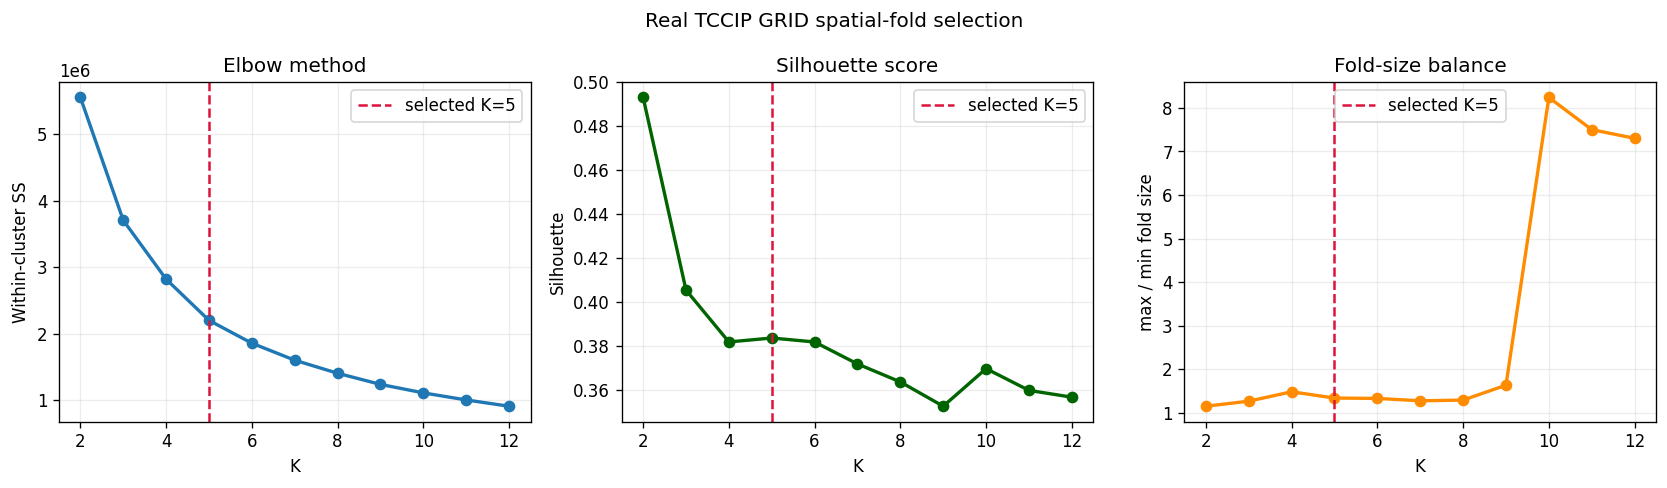

,n_grid
spatial_fold,
0,250
1,298
2,335
3,260
4,269


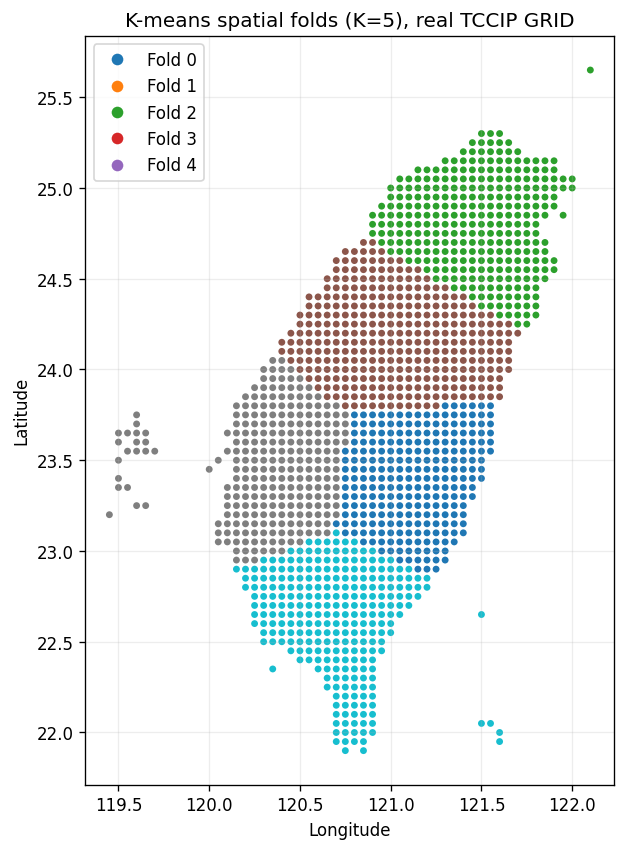

In [4]:
xy_km = df[["x_km", "y_km"]].to_numpy(float)
k_rows = []
labels_by_k = {}
for k in range(2, 13):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = model.fit_predict(xy_km)
    labels_by_k[k] = labels
    counts = pd.Series(labels).value_counts()
    k_rows.append({
        "K": k,
        "inertia": float(model.inertia_),
        "silhouette": float(silhouette_score(xy_km, labels)),
        "min_fold_size": int(counts.min()),
        "max_fold_size": int(counts.max()),
        "fold_size_ratio": float(counts.max() / counts.min()),
    })

k_selection = pd.DataFrame(k_rows)
k_selection.to_csv(
    TABLE_DIR / "spatial_validation_kmeans_fold_selection.csv",
    index=False,
    encoding="utf-8-sig",
)
display(k_selection.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))
axes[0].plot(k_selection["K"], k_selection["inertia"], "o-", lw=2)
axes[0].set(title="Elbow method", xlabel="K", ylabel="Within-cluster SS")
axes[1].plot(k_selection["K"], k_selection["silhouette"], "o-", lw=2, color="darkgreen")
axes[1].set(title="Silhouette score", xlabel="K", ylabel="Silhouette")
axes[2].plot(k_selection["K"], k_selection["fold_size_ratio"], "o-", lw=2, color="darkorange")
axes[2].set(title="Fold-size balance", xlabel="K", ylabel="max / min fold size")
for ax in axes:
    ax.axvline(SELECTED_K, color="crimson", ls="--", label="selected K=5")
    ax.legend()
fig.suptitle("Real TCCIP GRID spatial-fold selection")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_01_fold_selection.png", bbox_inches="tight")
plt.show()

df["spatial_fold"] = labels_by_k[SELECTED_K]
fold_counts = df["spatial_fold"].value_counts().sort_index().rename("n_grid")
display(fold_counts.to_frame())

fig, ax = plt.subplots(figsize=(6.5, 7.2))
scatter = ax.scatter(
    df["x_km"], df["y_km"],
    c=df["spatial_fold"], cmap="tab10", s=17, linewidths=0,
)
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.cm.tab10(i),
           label=f"Fold {i}", markersize=8)
    for i in range(SELECTED_K)
]
ax.legend(handles=handles, loc="upper left")
ax.set(
    title="K-means spatial folds (K=5), real TCCIP GRID",
    xlabel="TWD97 Easting (km)",
    ylabel="TWD97 Northing (km)",
)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_02_k5_folds.png", bbox_inches="tight")
plt.show()

df[["station", "lon", "lat", "x_km", "y_km", "spatial_fold"]].to_csv(
    TABLE_DIR / "spatial_validation_k5_fold_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

## 4. Valavi：Fitted variogram 與 effective range

現有 empirical variogram 只顯示距離分箱後的 semivariance，不能直接讀出 range。
這裡對每個 GEV response 比較 spherical、exponential、Gaussian variogram，
以 pair-count weighted RMSE 選擇擬合較佳者。

- Spherical 的 effective range 為參數 \(a\)；
- Exponential 取 \(3a\)（約達 sill 的 95%）；
- Gaussian 取 \(\sqrt{3}a\)（約達 sill 的 95%）。

為避免極少數最遠點對主導結果，variogram 最大 lag 設為全體最大 pair distance 的 50%。
這是將 Valavi 對 raw response / predictor spatial structure 的原則應用於
\(\hat\mu,\log\hat\sigma,\hat\xi\)，不是把這三者誤稱為 predictor rasters。

,target,model,nugget,partial_sill,sill,scale_parameter_km,effective_range_km,weighted_rmse
0,mu,gaussian,0.00000,19.31912,19.31912,29.57769,51.23006,2.15438
1,mu,spherical,0.00000,19.31934,19.31934,64.93493,64.93493,2.16466
2,mu,exponential,0.00000,19.33963,19.33963,21.69175,65.07525,2.63865
3,log_sigma,gaussian,0.05084,0.08565,0.13649,20.05368,34.73400,0.00617
4,log_sigma,exponential,0.00000,0.13700,0.13700,12.62706,37.88119,0.00617
5,log_sigma,spherical,0.03592,0.10053,0.13645,41.05167,41.05167,0.00620
6,xi,spherical,0.00146,0.01236,0.01382,28.36147,28.36147,0.00105
7,xi,gaussian,0.00322,0.01060,0.01382,13.69092,23.71337,0.00106
8,xi,exponential,0.00000,0.01382,0.01382,8.35824,25.07472,0.00111


Selected variogram model and effective range:


,target,model,nugget,sill,effective_range_km,weighted_rmse
0,log_sigma,gaussian,0.0508,0.1365,34.7340,0.0062
1,mu,gaussian,0.0000,19.3191,51.2301,2.1544
2,xi,spherical,0.0015,0.0138,28.3615,0.0011


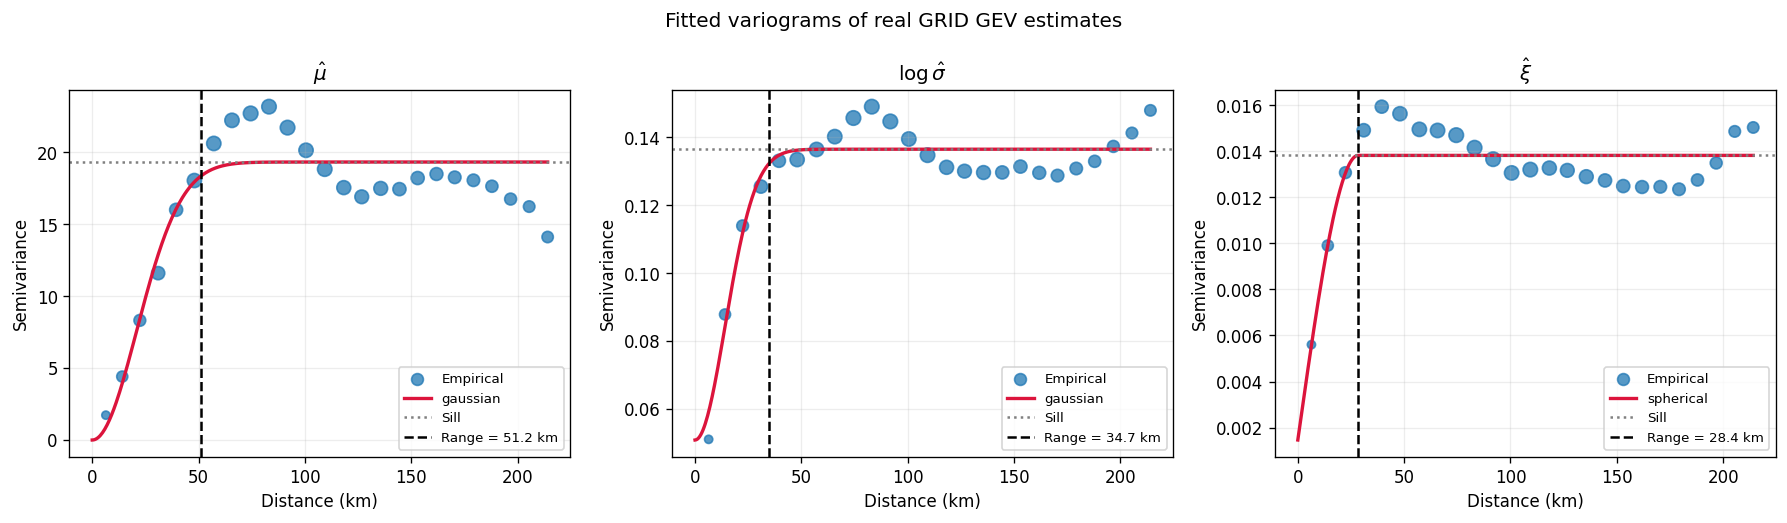

In [5]:
def spherical_variogram(h, nugget, partial_sill, scale):
    q = np.minimum(np.asarray(h) / scale, 1.0)
    return nugget + partial_sill * np.where(
        np.asarray(h) < scale,
        1.5 * q - 0.5 * q ** 3,
        1.0,
    )


def exponential_variogram(h, nugget, partial_sill, scale):
    return nugget + partial_sill * (1.0 - np.exp(-np.asarray(h) / scale))


def gaussian_variogram(h, nugget, partial_sill, scale):
    return nugget + partial_sill * (1.0 - np.exp(-(np.asarray(h) / scale) ** 2))


VARIOGRAM_MODELS = {
    "spherical": (spherical_variogram, lambda a: a),
    "exponential": (exponential_variogram, lambda a: 3.0 * a),
    "gaussian": (gaussian_variogram, lambda a: math.sqrt(3.0) * a),
}


def empirical_variogram(xy, values, n_lags=25, maxlag_fraction=0.5):
    distances = pdist(np.asarray(xy, dtype=float))
    semivariance = 0.5 * pdist(
        np.asarray(values, dtype=float).reshape(-1, 1),
        metric="sqeuclidean",
    )
    max_lag = distances.max() * maxlag_fraction
    edges = np.linspace(0.0, max_lag, n_lags + 1)
    bin_id = np.digitize(distances, edges) - 1
    rows = []
    for i in range(n_lags):
        mask = bin_id == i
        if mask.any():
            rows.append({
                "lag_km": float(distances[mask].mean()),
                "semivariance": float(semivariance[mask].mean()),
                "n_pairs": int(mask.sum()),
            })
    return pd.DataFrame(rows), max_lag


def fit_variogram_models(xy, values, label, n_lags=25):
    empirical, max_lag = empirical_variogram(xy, values, n_lags=n_lags)
    h = empirical["lag_km"].to_numpy()
    g = empirical["semivariance"].to_numpy()
    counts = empirical["n_pairs"].to_numpy()
    weights = np.sqrt(counts / counts.max())
    sample_var = float(np.var(values, ddof=1))
    rows = []

    for model_name, (fn, effective_fn) in VARIOGRAM_MODELS.items():
        lower = [0.0, 1e-12, max(h[0] / 2, 1e-3)]
        upper = [
            max(g.max() * 2, sample_var * 2, 1e-6),
            max(g.max() * 5, sample_var * 5, 1e-6),
            max_lag * 3,
        ]
        p0 = [
            max(0.0, g[0] * 0.2),
            max(sample_var, g.max() - g[0], 1e-6),
            max_lag / 4,
        ]
        params, _ = curve_fit(
            fn, h, g,
            p0=p0,
            bounds=(lower, upper),
            sigma=1.0 / np.maximum(weights, 1e-8),
            absolute_sigma=False,
            maxfev=50_000,
        )
        fitted = fn(h, *params)
        weighted_rmse = float(np.sqrt(np.average((g - fitted) ** 2, weights=counts)))
        rows.append({
            "target": label,
            "model": model_name,
            "nugget": params[0],
            "partial_sill": params[1],
            "sill": params[0] + params[1],
            "scale_parameter_km": params[2],
            "effective_range_km": effective_fn(params[2]),
            "weighted_rmse": weighted_rmse,
        })
    fits = pd.DataFrame(rows).sort_values("weighted_rmse").reset_index(drop=True)
    empirical["target"] = label
    return empirical, fits


empirical_parts = []
variogram_fit_parts = []
for target, target_col in TARGETS.items():
    empirical, fits = fit_variogram_models(xy_km, df[target_col].to_numpy(), target)
    empirical_parts.append(empirical)
    variogram_fit_parts.append(fits)

empirical_variograms = pd.concat(empirical_parts, ignore_index=True)
variogram_fits = pd.concat(variogram_fit_parts, ignore_index=True)
best_variograms = (
    variogram_fits.loc[
        variogram_fits.groupby("target")["weighted_rmse"].idxmin()
    ]
    .sort_values("target")
    .reset_index(drop=True)
)

empirical_variograms.to_csv(
    TABLE_DIR / "spatial_validation_empirical_variograms.csv",
    index=False,
    encoding="utf-8-sig",
)
variogram_fits.to_csv(
    TABLE_DIR / "spatial_validation_variogram_model_fits.csv",
    index=False,
    encoding="utf-8-sig",
)
display(variogram_fits.round(5))
print("Selected variogram model and effective range:")
display(
    best_variograms[
        ["target", "model", "nugget", "sill", "effective_range_km", "weighted_rmse"]
    ].round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, target in zip(axes, TARGETS):
    empirical = empirical_variograms.query("target == @target")
    best = best_variograms.query("target == @target").iloc[0]
    fn, _ = VARIOGRAM_MODELS[best["model"]]
    h_line = np.linspace(0, empirical["lag_km"].max(), 400)
    y_line = fn(
        h_line,
        best["nugget"],
        best["partial_sill"],
        best["scale_parameter_km"],
    )
    ax.scatter(
        empirical["lag_km"], empirical["semivariance"],
        s=np.sqrt(empirical["n_pairs"]) / 3,
        alpha=0.75, label="Empirical",
    )
    ax.plot(h_line, y_line, color="crimson", lw=2, label=best["model"])
    ax.axhline(best["sill"], color="gray", ls=":", label="Sill")
    ax.axvline(
        best["effective_range_km"],
        color="black", ls="--",
        label=f"Range = {best['effective_range_km']:.1f} km",
    )
    ax.set(
        title=TARGET_LABELS[target],
        xlabel="Distance (km)",
        ylabel="Semivariance",
    )
    ax.legend(fontsize=8)
fig.suptitle("Fitted variograms of real GRID GEV estimates")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_03_variogram_ranges.png", bbox_inches="tight")
plt.show()

## 5. 所有候選 Kernel 的 K=5 Spatial CV（未加 buffer）

這一步固定 K=5 folds，每次留一個區域作 test。每個 fold 的候選 training data
先以固定 seed 取最多 800 個 GRID，確保所有 kernel 比較使用相同資料。

這是 \(r_\delta=0\) 的 spatial CV，也是後續 SKCV 的 base pool。

In [6]:
base_pool_by_fold = {}
for fold in range(SELECTED_K):
    candidate_idx = df.index[df["spatial_fold"] != fold].to_numpy()
    base_pool_by_fold[fold] = sample_indices(
        candidate_idx,
        MAX_BASE_TRAIN,
        RANDOM_STATE + 10_000 + fold,
    )


def fit_gp_predict(
    train_indices,
    test_indices,
    target_col,
    kernel,
    optimize=True,
    n_restarts=0,
    fixed_scaler=None,
):
    train_indices = np.asarray(train_indices, dtype=int)
    test_indices = np.asarray(test_indices, dtype=int)
    train_xy = df.loc[train_indices, ["x_km", "y_km"]].to_numpy(float)
    test_xy = df.loc[test_indices, ["x_km", "y_km"]].to_numpy(float)

    if fixed_scaler is None:
        X_train, X_test, mean, scale = center_xy_km(train_xy, test_xy)
    else:
        mean, scale = fixed_scaler
        X_train = (train_xy - mean) / scale
        X_test = (test_xy - mean) / scale

    y_train = df.loc[train_indices, target_col].to_numpy(float)
    gp = GaussianProcessRegressor(
        kernel=clone(kernel),
        optimizer="fmin_l_bfgs_b" if optimize else None,
        n_restarts_optimizer=n_restarts if optimize else 0,
        normalize_y=True,
        random_state=RANDOM_STATE,
    )
    gp.fit(X_train, y_train)
    pred = gp.predict(X_test)
    return pred, gp.kernel_, (mean, scale)


kernel_cv_rows = []
kernel_cv_predictions = []
start = time.time()
for target, target_col in TARGETS.items():
    for spec in KERNEL_SPECS:
        for fold in range(SELECTED_K):
            train_idx = base_pool_by_fold[fold]
            test_idx = df.index[df["spatial_fold"] == fold].to_numpy()
            pred, fitted_kernel, _ = fit_gp_predict(
                train_idx,
                test_idx,
                target_col,
                make_kernel(
                    spec["kernel"],
                    None if pd.isna(spec["nu"]) else spec["nu"],
                ),
                optimize=True,
                n_restarts=0,
            )
            y_true = df.loc[test_idx, target_col].to_numpy(float)
            error = pred - y_true
            kernel_cv_rows.append({
                "target": target,
                "kernel": spec["kernel"],
                "nu": spec["nu"],
                "fold": fold,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "RMSE": float(np.sqrt(np.mean(error ** 2))),
                "MAE": float(np.mean(np.abs(error))),
                "Bias": float(np.mean(error)),
                "fitted_kernel": str(fitted_kernel),
            })
            kernel_cv_predictions.append(pd.DataFrame({
                "target": target,
                "kernel": spec["kernel"],
                "nu": spec["nu"],
                "fold": fold,
                "row_index": test_idx,
                "y_true": y_true,
                "y_pred": pred,
                "error": error,
            }))

kernel_fold_metrics = pd.DataFrame(kernel_cv_rows)
kernel_oof = pd.concat(kernel_cv_predictions, ignore_index=True)

kernel_cv_summary_rows = []
for (target, kernel, nu), part in kernel_oof.groupby(
    ["target", "kernel", "nu"], dropna=False
):
    error = part["error"].to_numpy()
    kernel_cv_summary_rows.append({
        "target": target,
        "kernel": kernel,
        "nu": nu,
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "MAE": float(np.mean(np.abs(error))),
        "Bias": float(np.mean(error)),
        "fold_RMSE_sd": float(
            kernel_fold_metrics.query(
                "target == @target and kernel == @kernel"
            ).loc[
                lambda x: (
                    x["nu"].isna() if pd.isna(nu)
                    else np.isclose(x["nu"], nu, equal_nan=False)
                ),
                "RMSE",
            ].std(ddof=1)
        ),
    })

kernel_cv_summary = (
    pd.DataFrame(kernel_cv_summary_rows)
    .sort_values(["target", "RMSE"])
    .reset_index(drop=True)
)
kernel_fold_metrics.to_csv(
    TABLE_DIR / "spatial_validation_kernel_cv_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
kernel_cv_summary.to_csv(
    TABLE_DIR / "spatial_validation_kernel_cv_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"Kernel CV runtime: {(time.time() - start) / 60:.1f} min")
display(kernel_cv_summary.round(5))

Kernel CV runtime: 2.1 min


,target,kernel,nu,RMSE,MAE,Bias,fold_RMSE_sd
0,log_sigma,Matern,0.5,0.32810,0.25219,0.03538,0.03995
1,log_sigma,Matern,1.5,0.34045,0.25985,0.01901,0.04220
2,log_sigma,Matern,2.5,0.34415,0.26172,0.01484,0.04303
3,log_sigma,RBF,NaN,0.34995,0.26516,0.00973,0.04241
4,mu,Matern,1.5,2.72935,2.17726,-0.75401,0.78807
5,mu,Matern,0.5,2.77353,2.04601,-0.77580,1.35416
6,mu,Matern,2.5,2.99121,2.40327,-0.82764,0.68672
7,mu,RBF,NaN,3.01852,2.44624,-0.58913,0.62265
8,xi,Matern,1.5,0.11276,0.08995,-0.00778,0.01294
9,xi,Matern,2.5,0.11300,0.09000,-0.00616,0.01386


In [7]:
best_kernel_rows = []
for target in TARGETS:
    part = kernel_cv_summary.query("target == @target").sort_values("RMSE")
    best = part.iloc[0]
    aic_best = aic_results.query("target == @target").sort_values("AIC").iloc[0]
    best_kernel_rows.append({
        "target": target,
        "selected_kernel": best["kernel"],
        "selected_nu": best["nu"],
        "spatial_cv_RMSE": best["RMSE"],
        "AIC_best_kernel": aic_best["kernel"],
        "AIC_best_nu": aic_best["nu"],
        "AIC_and_CV_agree": (
            best["kernel"] == aic_best["kernel"]
            and (
                (pd.isna(best["nu"]) and pd.isna(aic_best["nu"]))
                or (
                    pd.notna(best["nu"])
                    and pd.notna(aic_best["nu"])
                    and np.isclose(best["nu"], aic_best["nu"])
                )
            )
        ),
    })

selected_kernels = pd.DataFrame(best_kernel_rows)
selected_kernels.to_csv(
    TABLE_DIR / "spatial_validation_selected_kernels.csv",
    index=False,
    encoding="utf-8-sig",
)
display(selected_kernels.round(5))

,target,selected_kernel,selected_nu,spatial_cv_RMSE,AIC_best_kernel,AIC_best_nu,AIC_and_CV_agree
0,mu,Matern,1.5,2.72935,Matern,0.5,False
1,log_sigma,Matern,0.5,0.32810,Matern,0.5,True
2,xi,Matern,1.5,0.11276,Matern,0.5,False


## 6. Pohjankukka：Buffered SKCV 與 SKCV-RLO

對 fold \(f\) 與距離 \(r_\delta\)：

候選距離保留 0、10、20 km 作為基準，並在 variogram effective range 所在的
30--70 km 區間以 5 km 間距加密。Effective range 是候選尺度的統計依據，
不是由最低 RMSE 決定的「最佳距離」；報告距離取不小於 effective range 的最小可行候選值。

1. Fold \(f\) 為 test；
2. 其餘 folds 先形成固定、最多 800 點的 base pool；
3. SKCV 刪除距離任一 test GRID 不超過 \(r_\delta\) 的 base training GRID；
4. 記錄刪除數 \(m_{f,r}\)；
5. SKCV-RLO 從**相同 base pool**隨機刪除相同的 \(m_{f,r}\) 點；
6. RLO 重複多個 random seeds，報告 mean ± SD。

為公平比較距離效應，kernel family 先由前一節固定。每個 fold 的 kernel hyperparameters
只使用該 fold 的 base training pool 最佳化一次；不同 radius 與 RLO 使用相同已固定超參數，
避免把重複調參差異誤認為空間距離效應。

In [8]:
effective_ranges = dict(
    zip(best_variograms["target"], best_variograms["effective_range_km"])
)
max_range = max(effective_ranges.values())
coarse_radii_km = np.array([0, 10, 20], dtype=float)
fine_radii_km = np.arange(30, 71, 5, dtype=float)
RADII_KM = np.unique(np.concatenate([coarse_radii_km, fine_radii_km]))
if RADII_KM.max() < max_range:
    raise ValueError("Candidate radii do not cover the largest effective range.")
print("Effective ranges (km):", {k: round(v, 2) for k, v in effective_ranges.items()})
print("Candidate radii (km):", RADII_KM.tolist())


def spec_to_kernel(row):
    return make_kernel(
        row["selected_kernel"],
        None if pd.isna(row["selected_nu"]) else float(row["selected_nu"]),
    )


# 每個 target/fold 僅使用 base training 最佳化一次 hyperparameters。
fitted_base = {}
base_fit_rows = []
for target, target_col in TARGETS.items():
    selected_row = selected_kernels.query("target == @target").iloc[0]
    for fold in range(SELECTED_K):
        train_idx = base_pool_by_fold[fold]
        test_idx = df.index[df["spatial_fold"] == fold].to_numpy()
        _, fitted_kernel, scaler = fit_gp_predict(
            train_idx,
            test_idx,
            target_col,
            spec_to_kernel(selected_row),
            optimize=True,
            n_restarts=0,
        )
        fitted_base[(target, fold)] = {
            "kernel": fitted_kernel,
            "scaler": scaler,
        }
        base_fit_rows.append({
            "target": target,
            "fold": fold,
            "n_base_train": len(train_idx),
            "fitted_kernel": str(fitted_kernel),
        })
base_fit_info = pd.DataFrame(base_fit_rows)
display(base_fit_info)

Effective ranges (km): {'log_sigma': 34.73, 'mu': 51.23, 'xi': 28.36}
Candidate radii (km): [0.0, 10.0, 20.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0]


,target,fold,n_base_train,fitted_kernel
0,mu,0,800,"0.811**2 * Matern(length_scale=0.351, nu=1.5) ..."
1,mu,1,800,"0.816**2 * Matern(length_scale=0.488, nu=1.5) ..."
2,mu,2,800,"0.793**2 * Matern(length_scale=0.303, nu=1.5) ..."
3,mu,3,800,"0.819**2 * Matern(length_scale=0.407, nu=1.5) ..."
4,mu,4,800,"0.777**2 * Matern(length_scale=0.337, nu=1.5) ..."
5,log_sigma,0,800,"0.956**2 * Matern(length_scale=0.182, nu=0.5) ..."
6,log_sigma,1,800,"0.921**2 * Matern(length_scale=0.253, nu=0.5) ..."
7,log_sigma,2,800,"0.911**2 * Matern(length_scale=0.233, nu=0.5) ..."
8,log_sigma,3,800,"0.944**2 * Matern(length_scale=0.217, nu=0.5) ..."
9,log_sigma,4,800,"0.953**2 * Matern(length_scale=0.201, nu=0.5) ..."


In [9]:
def min_distance_to_test(train_indices, test_indices):
    train_xy = df.loc[train_indices, ["x_km", "y_km"]].to_numpy(float)
    test_xy = df.loc[test_indices, ["x_km", "y_km"]].to_numpy(float)
    nn = NearestNeighbors(n_neighbors=1).fit(test_xy)
    distance, _ = nn.kneighbors(train_xy)
    return distance[:, 0]


distance_cache = {}
for fold in range(SELECTED_K):
    base_idx = base_pool_by_fold[fold]
    test_idx = df.index[df["spatial_fold"] == fold].to_numpy()
    distance_cache[fold] = min_distance_to_test(base_idx, test_idx)

metric_rows = []
skcv_prediction_parts = []
start = time.time()

for target_order, (target, target_col) in enumerate(TARGETS.items()):
    for radius in RADII_KM:
        for fold in range(SELECTED_K):
            base_idx = base_pool_by_fold[fold]
            test_idx = df.index[df["spatial_fold"] == fold].to_numpy()
            distance_to_test = distance_cache[fold]
            keep_mask = distance_to_test > radius
            skcv_train_idx = base_idx[keep_mask]
            n_removed = int((~keep_mask).sum())

            if len(skcv_train_idx) < MIN_TRAIN:
                metric_rows.append({
                    "target": target, "method": "SKCV", "radius_km": radius,
                    "fold": fold, "repeat": 0, "n_base_train": len(base_idx),
                    "n_removed": n_removed, "n_train": len(skcv_train_idx),
                    "n_test": len(test_idx), "RMSE": np.nan, "MAE": np.nan,
                    "Bias": np.nan, "feasible": False,
                })
                continue

            model_info = fitted_base[(target, fold)]
            pred, _, _ = fit_gp_predict(
                skcv_train_idx,
                test_idx,
                target_col,
                model_info["kernel"],
                optimize=False,
                fixed_scaler=model_info["scaler"],
            )
            y_true = df.loc[test_idx, target_col].to_numpy(float)
            error = pred - y_true
            metric_rows.append({
                "target": target, "method": "SKCV", "radius_km": radius,
                "fold": fold, "repeat": 0, "n_base_train": len(base_idx),
                "n_removed": n_removed, "n_train": len(skcv_train_idx),
                "n_test": len(test_idx),
                "RMSE": float(np.sqrt(np.mean(error ** 2))),
                "MAE": float(np.mean(np.abs(error))),
                "Bias": float(np.mean(error)),
                "feasible": True,
            })
            skcv_prediction_parts.append(pd.DataFrame({
                "target": target,
                "method": "SKCV",
                "radius_km": radius,
                "fold": fold,
                "row_index": test_idx,
                "station": df.loc[test_idx, "station"].to_numpy(),
                "y_true": y_true,
                "y_pred": pred,
                "error": error,
            }))

            # r=0 時 RLO 與 SKCV 完全相同，不重複配適。
            rlo_repeat_range = [0] if radius == 0 else range(RLO_REPEATS)
            for repeat in rlo_repeat_range:
                if radius == 0:
                    rlo_train_idx = skcv_train_idx
                    rlo_pred = pred
                    rlo_error = error
                else:
                    rng = np.random.default_rng(
                        RANDOM_STATE
                        + target_order * 100_000
                        + int(radius) * 100
                        + fold * 10
                        + repeat
                    )
                    if n_removed:
                        removed = rng.choice(base_idx, size=n_removed, replace=False)
                        rlo_train_idx = base_idx[~np.isin(base_idx, removed)]
                    else:
                        rlo_train_idx = base_idx
                    rlo_pred, _, _ = fit_gp_predict(
                        rlo_train_idx,
                        test_idx,
                        target_col,
                        model_info["kernel"],
                        optimize=False,
                        fixed_scaler=model_info["scaler"],
                    )
                    rlo_error = rlo_pred - y_true
                metric_rows.append({
                    "target": target, "method": "SKCV-RLO", "radius_km": radius,
                    "fold": fold, "repeat": repeat,
                    "n_base_train": len(base_idx), "n_removed": n_removed,
                    "n_train": len(rlo_train_idx), "n_test": len(test_idx),
                    "RMSE": float(np.sqrt(np.mean(rlo_error ** 2))),
                    "MAE": float(np.mean(np.abs(rlo_error))),
                    "Bias": float(np.mean(rlo_error)),
                    "feasible": True,
                })

skcv_fold_metrics = pd.DataFrame(metric_rows)
skcv_predictions = pd.concat(skcv_prediction_parts, ignore_index=True)
skcv_fold_metrics.to_csv(
    TABLE_DIR / "spatial_validation_skcv_rlo_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
skcv_predictions.to_csv(
    TABLE_DIR / "spatial_validation_skcv_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"SKCV/RLO runtime: {(time.time() - start) / 60:.1f} min")
display(skcv_fold_metrics.head())

SKCV/RLO runtime: 0.5 min


,target,method,radius_km,fold,repeat,n_base_train,n_removed,n_train,n_test,RMSE,MAE,Bias,feasible
0,mu,SKCV,0.0,0,0,800,0,800,250,3.566251,2.738340,1.512850,True
1,mu,SKCV-RLO,0.0,0,0,800,0,800,250,3.566251,2.738340,1.512850,True
2,mu,SKCV,0.0,1,0,800,0,800,298,3.396383,3.022952,-3.005117,True
3,mu,SKCV-RLO,0.0,1,0,800,0,800,298,3.396383,3.022952,-3.005117,True
4,mu,SKCV,0.0,2,0,800,0,800,335,2.238032,1.628973,0.720464,True


In [10]:
def aggregate_fold_metrics(metrics):
    # 先按 target/method/radius/repeat 合併五個 folds 的加權 MSE/MAE/Bias。
    rows = []
    valid = metrics.query("feasible == True").copy()
    for keys, part in valid.groupby(
        ["target", "method", "radius_km", "repeat"], dropna=False
    ):
        target, method, radius, repeat = keys
        n = part["n_test"].to_numpy(float)
        rows.append({
            "target": target,
            "method": method,
            "radius_km": radius,
            "repeat": repeat,
            "RMSE": float(np.sqrt(np.average(part["RMSE"] ** 2, weights=n))),
            "MAE": float(np.average(part["MAE"], weights=n)),
            "Bias": float(np.average(part["Bias"], weights=n)),
            "mean_n_train": float(part["n_train"].mean()),
            "min_n_train": int(part["n_train"].min()),
            "mean_retention": float((part["n_train"] / part["n_base_train"]).mean()),
            "n_folds": int(part["fold"].nunique()),
        })
    return pd.DataFrame(rows)


curve_by_repeat = aggregate_fold_metrics(skcv_fold_metrics)
curve_rows = []
for keys, part in curve_by_repeat.groupby(
    ["target", "method", "radius_km"], dropna=False
):
    target, method, radius = keys
    curve_rows.append({
        "target": target,
        "method": method,
        "radius_km": radius,
        "RMSE_mean": part["RMSE"].mean(),
        "RMSE_sd": part["RMSE"].std(ddof=1) if len(part) > 1 else 0.0,
        "MAE_mean": part["MAE"].mean(),
        "MAE_sd": part["MAE"].std(ddof=1) if len(part) > 1 else 0.0,
        "Bias_mean": part["Bias"].mean(),
        "Bias_sd": part["Bias"].std(ddof=1) if len(part) > 1 else 0.0,
        "mean_n_train": part["mean_n_train"].mean(),
        "min_n_train": part["min_n_train"].min(),
        "mean_retention": part["mean_retention"].mean(),
        "n_folds": part["n_folds"].min(),
        "n_repeats": len(part),
    })
curve_summary = pd.DataFrame(curve_rows)
curve_by_repeat.to_csv(
    TABLE_DIR / "spatial_validation_skcv_rlo_by_repeat.csv",
    index=False,
    encoding="utf-8-sig",
)
curve_summary.to_csv(
    TABLE_DIR / "spatial_validation_skcv_rlo_curve_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(curve_summary.round(5))

,target,method,radius_km,RMSE_mean,RMSE_sd,MAE_mean,MAE_sd,Bias_mean,Bias_sd,mean_n_train,min_n_train,mean_retention,n_folds,n_repeats
0,log_sigma,SKCV,0.0,0.32810,0.00000,0.25219,0.00000,0.03538,0.00000,800.0,800,1.00000,5,1
1,log_sigma,SKCV,10.0,0.33809,0.00000,0.25801,0.00000,0.01583,0.00000,768.8,758,0.96100,5,1
2,log_sigma,SKCV,20.0,0.36387,0.00000,0.27292,0.00000,0.00413,0.00000,711.2,679,0.88900,5,1
3,log_sigma,SKCV,30.0,0.37177,0.00000,0.27841,0.00000,-0.01762,0.00000,664.6,618,0.83075,5,1
4,log_sigma,SKCV,35.0,0.37384,0.00000,0.28049,0.00000,-0.01484,0.00000,634.0,581,0.79250,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,xi,SKCV-RLO,50.0,0.11339,0.00028,0.09058,0.00029,-0.00703,0.00140,545.6,458,0.68200,5,5
68,xi,SKCV-RLO,55.0,0.11349,0.00041,0.09024,0.00032,-0.00688,0.00093,518.8,418,0.64850,5,5
69,xi,SKCV-RLO,60.0,0.11416,0.00098,0.09109,0.00075,-0.00763,0.00157,489.4,373,0.61175,5,5
70,xi,SKCV-RLO,65.0,0.11321,0.00055,0.09058,0.00042,-0.00728,0.00144,456.6,324,0.57075,5,5


## 7. 核心結果圖：SKCV vs SKCV-RLO

解讀原則：

- SKCV 隨距離變差、RLO 大致不變：誤差增加主要來自移除空間鄰近資訊；
- 兩者一起變差：training sample size 減少也有明顯影響；
- 兩者都穩定：測試距離範圍內的鄰近偏誤不明顯。

Report radius: smallest candidate >= effective range
{'mu': 55.0, 'log_sigma': 35.0, 'xi': 30.0}


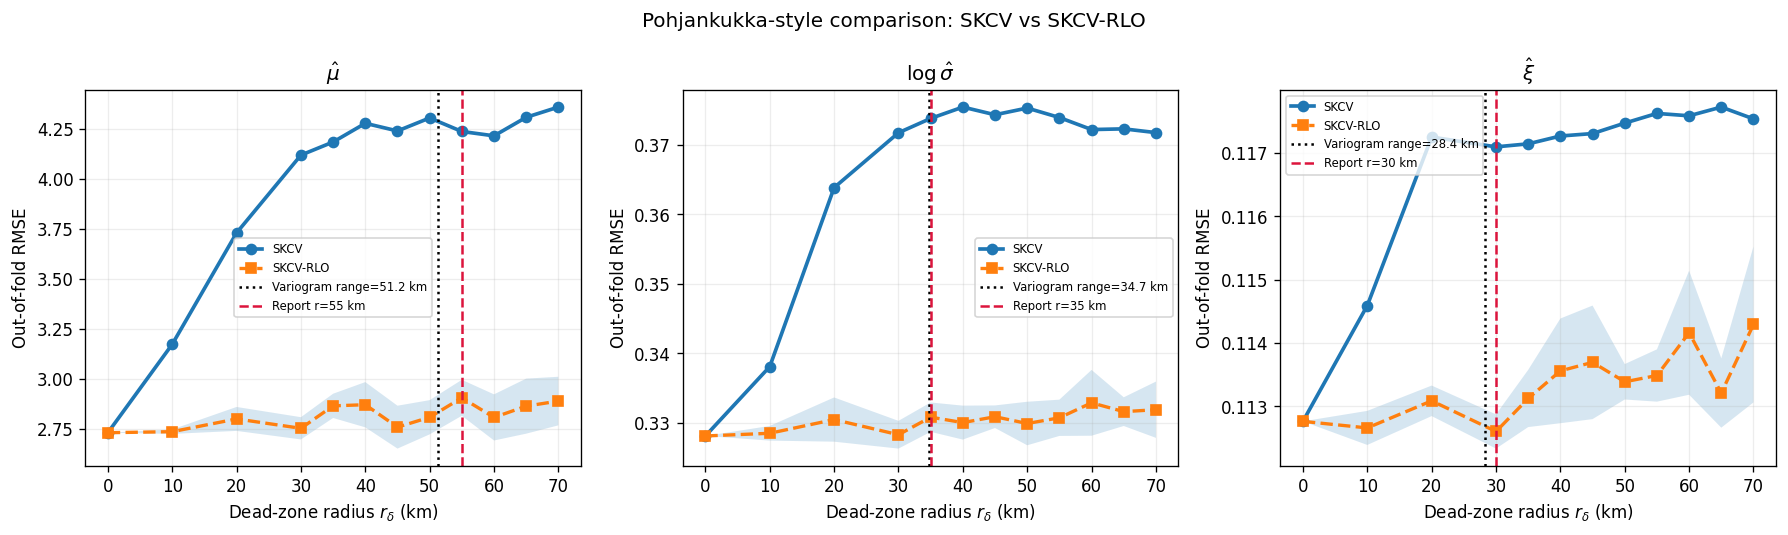

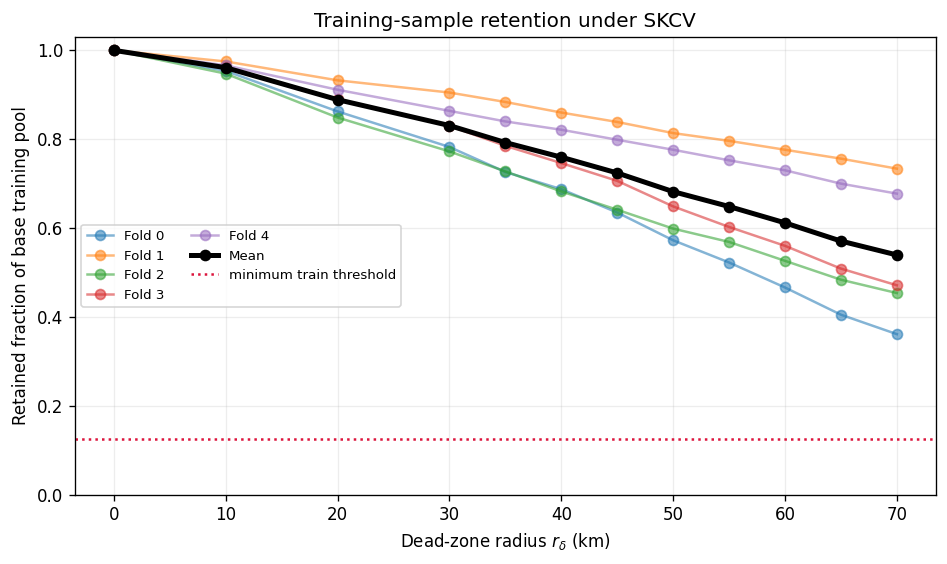

In [11]:
selected_radius = {
    target: float(RADII_KM[RADII_KM >= effective_ranges[target]][0])
    for target in TARGETS
}
print("Report radius: smallest candidate >= effective range")
print(selected_radius)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, target in zip(axes, TARGETS):
    sk = curve_summary.query("target == @target and method == 'SKCV'").sort_values("radius_km")
    rl = curve_summary.query("target == @target and method == 'SKCV-RLO'").sort_values("radius_km")
    ax.plot(sk["radius_km"], sk["RMSE_mean"], "o-", lw=2.2, label="SKCV")
    ax.plot(rl["radius_km"], rl["RMSE_mean"], "s--", lw=2, label="SKCV-RLO")
    ax.fill_between(
        rl["radius_km"].to_numpy(float),
        (rl["RMSE_mean"] - rl["RMSE_sd"]).to_numpy(float),
        (rl["RMSE_mean"] + rl["RMSE_sd"]).to_numpy(float),
        alpha=0.18,
    )
    ax.axvline(
        effective_ranges[target], color="black", ls=":",
        label=f"Variogram range={effective_ranges[target]:.1f} km",
    )
    ax.axvline(
        selected_radius[target], color="crimson", ls="--",
        label=f"Report r={selected_radius[target]:.0f} km",
    )
    ax.set(
        title=TARGET_LABELS[target],
        xlabel=r"Dead-zone radius $r_\delta$ (km)",
        ylabel="Out-of-fold RMSE",
    )
    ax.legend(fontsize=7)
fig.suptitle("Pohjankukka-style comparison: SKCV vs SKCV-RLO")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_04_skcv_vs_rlo_rmse.png", bbox_inches="tight")
plt.show()

# Retention 與刪除數只由 fold/radius 決定，取 SKCV 的三個 target 平均會得到相同結果。
retention = (
    skcv_fold_metrics.query("method == 'SKCV' and feasible == True")
    .groupby(["fold", "radius_km"], as_index=False)
    .agg(
        n_train=("n_train", "first"),
        n_base=("n_base_train", "first"),
        n_removed=("n_removed", "first"),
    )
)
retention["retention"] = retention["n_train"] / retention["n_base"]
fig, ax = plt.subplots(figsize=(8, 4.8))
for fold, part in retention.groupby("fold"):
    ax.plot(part["radius_km"], part["retention"], "o-", alpha=0.55, label=f"Fold {fold}")
mean_ret = retention.groupby("radius_km", as_index=False)["retention"].mean()
ax.plot(
    mean_ret["radius_km"], mean_ret["retention"],
    "o-", color="black", lw=3, label="Mean",
)
ax.axhline(MIN_TRAIN / MAX_BASE_TRAIN, color="crimson", ls=":", label="minimum train threshold")
ax.set(
    title="Training-sample retention under SKCV",
    xlabel=r"Dead-zone radius $r_\delta$ (km)",
    ylabel="Retained fraction of base training pool",
    ylim=(0, 1.03),
)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_05_training_retention.png", bbox_inches="tight")
plt.show()

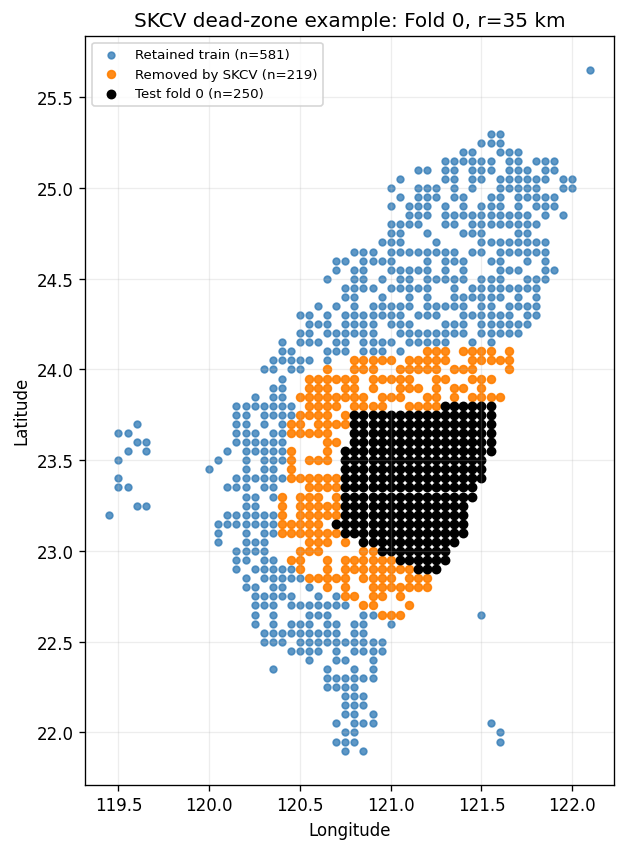

In [12]:
# Dead-zone 範例：Fold 0，採三個 report radii 的中位數。
example_fold = 0
example_radius = float(np.median(list(selected_radius.values())))
base_idx = base_pool_by_fold[example_fold]
test_idx = df.index[df["spatial_fold"] == example_fold].to_numpy()
dist = distance_cache[example_fold]
removed_idx = base_idx[dist <= example_radius]
retained_idx = base_idx[dist > example_radius]

fig, ax = plt.subplots(figsize=(6.7, 7.2))
ax.scatter(
    df.loc[retained_idx, "x_km"], df.loc[retained_idx, "y_km"],
    s=16, c="#377eb8", label=f"Retained train (n={len(retained_idx)})", alpha=0.8,
)
ax.scatter(
    df.loc[removed_idx, "x_km"], df.loc[removed_idx, "y_km"],
    s=22, c="#ff7f00", label=f"Removed by SKCV (n={len(removed_idx)})", alpha=0.9,
)
ax.scatter(
    df.loc[test_idx, "x_km"], df.loc[test_idx, "y_km"],
    s=24, c="black", label=f"Test fold {example_fold} (n={len(test_idx)})",
)
ax.set(
    title=f"SKCV dead-zone example: Fold {example_fold}, r={example_radius:.0f} km",
    xlabel="TWD97 Easting (km)",
    ylabel="TWD97 Northing (km)",
)
ax.set_aspect("equal")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_06_dead_zone_example.png", bbox_inches="tight")
plt.show()

## 8. 四種驗證方法比較

比較：

1. Random 5-fold；
2. K-means Spatial CV（即 \(r_\delta=0\)）；
3. target-specific report radius 的 SKCV；
4. 相同 radius 與刪除數的 SKCV-RLO。

Random CV 只作為展示樂觀偏誤的基準；最終空間泛化判斷以 SKCV 為主。

In [13]:
random_parts = []
random_fold_rows = []
kfold = KFold(n_splits=SELECTED_K, shuffle=True, random_state=RANDOM_STATE)
all_idx = df.index.to_numpy()

for target, target_col in TARGETS.items():
    selected_row = selected_kernels.query("target == @target").iloc[0]
    for fold, (train_pos, test_pos) in enumerate(kfold.split(all_idx)):
        candidate_train = all_idx[train_pos]
        test_idx = all_idx[test_pos]
        train_idx = sample_indices(
            candidate_train,
            MAX_BASE_TRAIN,
            RANDOM_STATE + 50_000 + fold,
        )
        pred, _, _ = fit_gp_predict(
            train_idx,
            test_idx,
            target_col,
            spec_to_kernel(selected_row),
            optimize=True,
            n_restarts=0,
        )
        y_true = df.loc[test_idx, target_col].to_numpy(float)
        error = pred - y_true
        random_parts.append(pd.DataFrame({
            "target": target,
            "method": "Random 5-fold",
            "fold": fold,
            "row_index": test_idx,
            "station": df.loc[test_idx, "station"].to_numpy(),
            "y_true": y_true,
            "y_pred": pred,
            "error": error,
        }))
        random_fold_rows.append({
            "target": target,
            "method": "Random 5-fold",
            "fold": fold,
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "MAE": float(np.mean(np.abs(error))),
            "Bias": float(np.mean(error)),
            "n_train": len(train_idx),
            "n_test": len(test_idx),
        })

random_predictions = pd.concat(random_parts, ignore_index=True)
random_fold_metrics = pd.DataFrame(random_fold_rows)

comparison_rows = []
comparison_fold_rows = [random_fold_metrics]
for target in TARGETS:
    # Random
    part = random_predictions.query("target == @target")
    comparison_rows.append({
        "target": target, "method": "Random 5-fold",
        "RMSE": float(np.sqrt(np.mean(part["error"] ** 2))),
        "MAE": float(np.mean(np.abs(part["error"]))),
        "Bias": float(np.mean(part["error"])),
    })

    # Spatial r=0 and selected SKCV from actual OOF predictions.
    for method_name, radius in [
        ("Spatial CV (r=0)", 0.0),
        ("SKCV (report r)", selected_radius[target]),
    ]:
        part = skcv_predictions.query(
            "target == @target and radius_km == @radius"
        )
        comparison_rows.append({
            "target": target, "method": method_name,
            "RMSE": float(np.sqrt(np.mean(part["error"] ** 2))),
            "MAE": float(np.mean(np.abs(part["error"]))),
            "Bias": float(np.mean(part["error"])),
        })
        folds = (
            part.groupby("fold")
            .apply(lambda x: pd.Series({
                "RMSE": np.sqrt(np.mean(x["error"] ** 2)),
                "MAE": np.mean(np.abs(x["error"])),
                "Bias": np.mean(x["error"]),
                "n_test": len(x),
            }), include_groups=False)
            .reset_index()
        )
        folds["target"] = target
        folds["method"] = method_name
        comparison_fold_rows.append(folds)

    # RLO 使用 repeats 的平均。
    report_r = selected_radius[target]
    rlo = curve_summary.query(
        "target == @target and method == 'SKCV-RLO' "
        "and radius_km == @report_r"
    ).iloc[0]
    comparison_rows.append({
        "target": target, "method": "SKCV-RLO (report r)",
        "RMSE": rlo["RMSE_mean"],
        "MAE": rlo["MAE_mean"],
        "Bias": rlo["Bias_mean"],
    })

method_comparison = pd.DataFrame(comparison_rows)
method_fold_metrics = pd.concat(comparison_fold_rows, ignore_index=True, sort=False)
method_comparison.to_csv(
    TABLE_DIR / "spatial_validation_method_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)
method_fold_metrics.to_csv(
    TABLE_DIR / "spatial_validation_method_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
random_predictions.to_csv(
    TABLE_DIR / "spatial_validation_random_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
display(method_comparison.round(5))

,target,method,RMSE,MAE,Bias
0,mu,Random 5-fold,1.09921,0.70559,0.00457
1,mu,Spatial CV (r=0),2.72935,2.17726,-0.75401
2,mu,SKCV (report r),4.23705,3.35493,0.40593
3,mu,SKCV-RLO (report r),2.90413,2.32534,-0.65526
4,log_sigma,Random 5-fold,0.22007,0.16204,0.00451
5,log_sigma,Spatial CV (r=0),0.32810,0.25219,0.03538
6,log_sigma,SKCV (report r),0.37384,0.28049,-0.01484
7,log_sigma,SKCV-RLO (report r),0.33081,0.25353,0.03836
8,xi,Random 5-fold,0.07392,0.05546,-0.00118
9,xi,Spatial CV (r=0),0.11276,0.08995,-0.00778


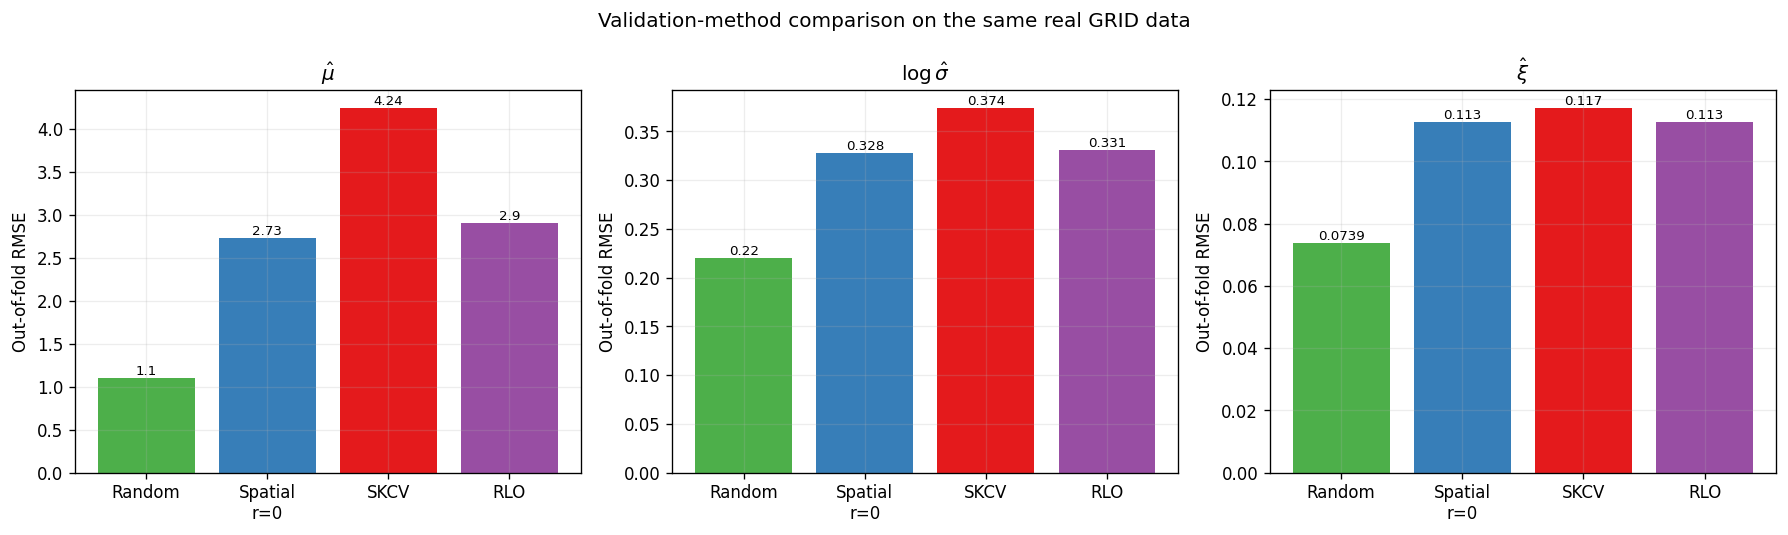

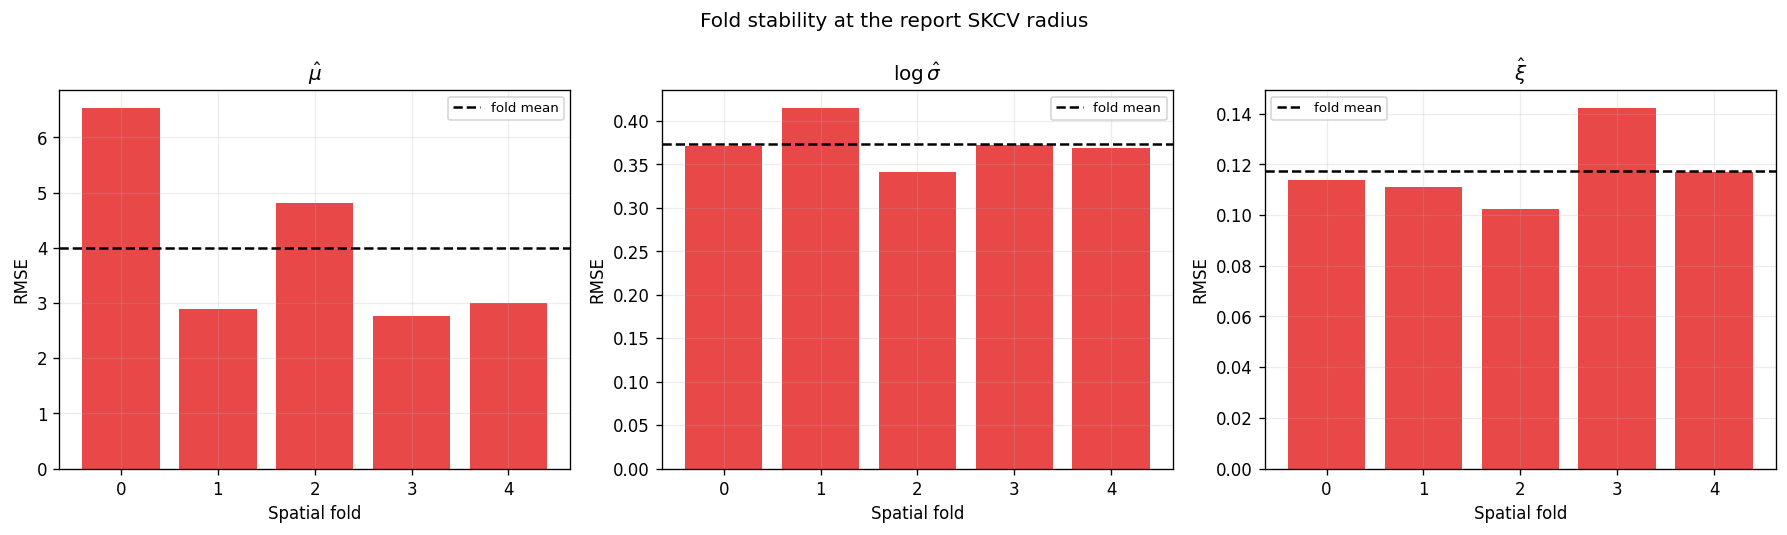

In [14]:
method_order = [
    "Random 5-fold",
    "Spatial CV (r=0)",
    "SKCV (report r)",
    "SKCV-RLO (report r)",
]
colors = ["#4daf4a", "#377eb8", "#e41a1c", "#984ea3"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, TARGETS):
    part = (
        method_comparison.query("target == @target")
        .set_index("method")
        .reindex(method_order)
        .reset_index()
    )
    ax.bar(range(len(part)), part["RMSE"], color=colors)
    ax.set_xticks(range(len(part)))
    ax.set_xticklabels(["Random", "Spatial\nr=0", "SKCV", "RLO"], rotation=0)
    ax.set(title=TARGET_LABELS[target], ylabel="Out-of-fold RMSE")
    for i, value in enumerate(part["RMSE"]):
        ax.text(i, value, f"{value:.3g}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Validation-method comparison on the same real GRID data")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_07_method_comparison.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, target in zip(axes, TARGETS):
    part = method_fold_metrics.query(
        "target == @target and method == 'SKCV (report r)'"
    )
    ax.bar(part["fold"].astype(int), part["RMSE"], color="#e41a1c", alpha=0.8)
    ax.axhline(part["RMSE"].mean(), color="black", ls="--", label="fold mean")
    ax.set(
        title=TARGET_LABELS[target],
        xlabel="Spatial fold",
        ylabel="RMSE",
        xticks=range(SELECTED_K),
    )
    ax.legend(fontsize=8)
fig.suptitle("Fold stability at the report SKCV radius")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_08_fold_rmse.png", bbox_inches="tight")
plt.show()

## 9. Out-of-fold residual spatial autocorrelation

Residual 使用 report radius 下的 SKCV out-of-fold prediction：

$$
e_i=y_i-\hat y_i.
$$

檢查：

- residual spatial map；
- fitted residual variogram；
- 8-nearest-neighbor Moran's I，搭配 999 次 permutation。

顯著 residual SAC 不只可能表示 buffer 太短，也可能來自 kernel 不適合、遺漏 predictor、
nonstationarity 或 anisotropy，因此不能只靠增加 buffer 解釋所有問題。

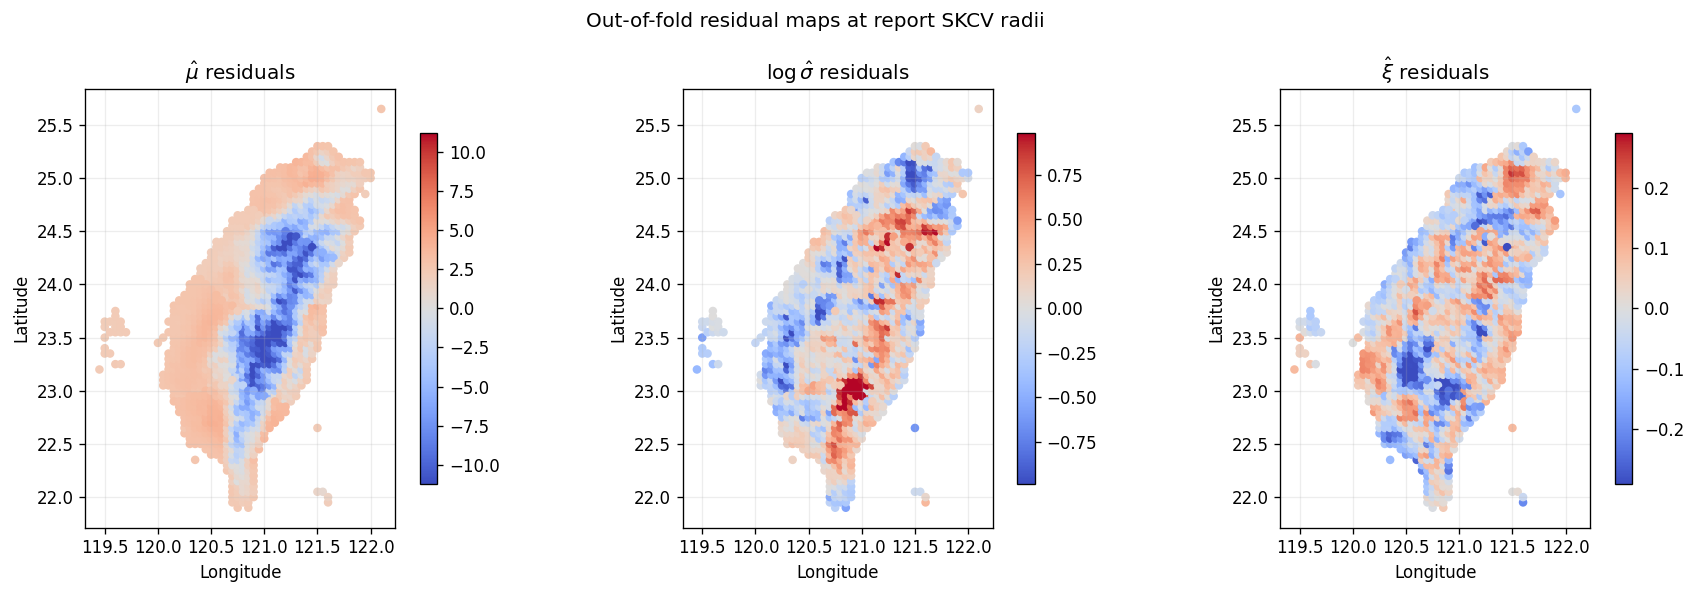

In [15]:
residual_parts = []
for target in TARGETS:
    radius = selected_radius[target]
    part = skcv_predictions.query(
        "target == @target and radius_km == @radius"
    ).copy()
    part["residual"] = part["y_true"] - part["y_pred"]
    part = part.merge(
        df[["lon", "lat", "x_km", "y_km"]],
        left_on="row_index",
        right_index=True,
        how="left",
    )
    residual_parts.append(part)
oof_residuals = pd.concat(residual_parts, ignore_index=True)
oof_residuals.to_csv(
    TABLE_DIR / "spatial_validation_selected_skcv_oof_residuals.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    part = oof_residuals.query("target == @target")
    limit = np.quantile(np.abs(part["residual"]), 0.98)
    sc = ax.scatter(
        part["x_km"], part["y_km"], c=part["residual"],
        cmap="coolwarm", vmin=-limit, vmax=limit, s=17,
    )
    ax.set(
        title=f"{TARGET_LABELS[target]} residuals",
        xlabel="TWD97 Easting (km)",
        ylabel="TWD97 Northing (km)",
    )
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, shrink=0.8)
fig.suptitle("Out-of-fold residual maps at report SKCV radii")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_09_residual_maps.png", bbox_inches="tight")
plt.show()

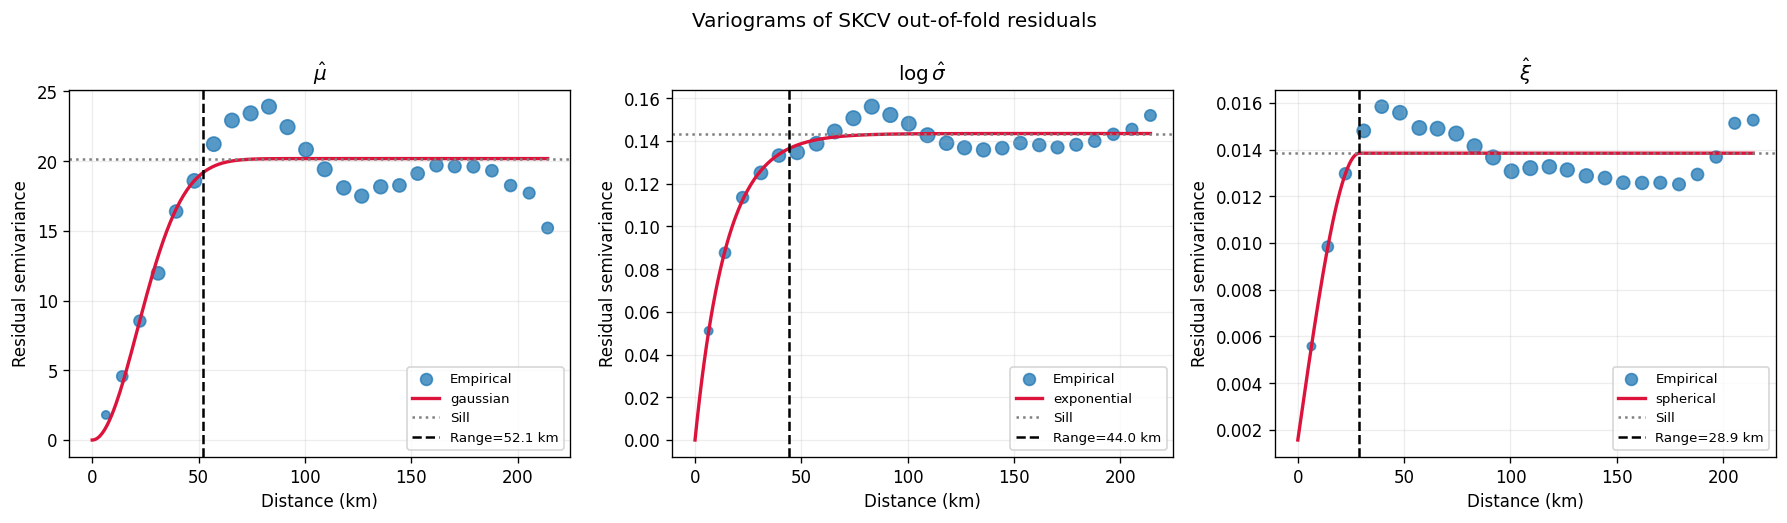

In [16]:
residual_empirical_parts = []
residual_fit_parts = []
for target in TARGETS:
    part = oof_residuals.query("target == @target").sort_values("row_index")
    empirical, fits = fit_variogram_models(
        part[["x_km", "y_km"]].to_numpy(),
        part["residual"].to_numpy(),
        target,
    )
    residual_empirical_parts.append(empirical)
    residual_fit_parts.append(fits)
residual_empirical = pd.concat(residual_empirical_parts, ignore_index=True)
residual_fits = pd.concat(residual_fit_parts, ignore_index=True)
best_residual_variograms = (
    residual_fits.loc[
        residual_fits.groupby("target")["weighted_rmse"].idxmin()
    ]
    .sort_values("target")
    .reset_index(drop=True)
)
residual_fits.to_csv(
    TABLE_DIR / "spatial_validation_residual_variogram_fits.csv",
    index=False,
    encoding="utf-8-sig",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, target in zip(axes, TARGETS):
    empirical = residual_empirical.query("target == @target")
    best = best_residual_variograms.query("target == @target").iloc[0]
    fn, _ = VARIOGRAM_MODELS[best["model"]]
    h_line = np.linspace(0, empirical["lag_km"].max(), 400)
    ax.scatter(
        empirical["lag_km"], empirical["semivariance"],
        s=np.sqrt(empirical["n_pairs"]) / 3, alpha=0.75, label="Empirical",
    )
    ax.plot(
        h_line,
        fn(h_line, best["nugget"], best["partial_sill"], best["scale_parameter_km"]),
        color="crimson", lw=2, label=best["model"],
    )
    ax.axhline(best["sill"], color="gray", ls=":", label="Sill")
    ax.axvline(
        best["effective_range_km"], color="black", ls="--",
        label=f"Range={best['effective_range_km']:.1f} km",
    )
    ax.set(
        title=TARGET_LABELS[target],
        xlabel="Distance (km)",
        ylabel="Residual semivariance",
    )
    ax.legend(fontsize=8)
fig.suptitle("Variograms of SKCV out-of-fold residuals")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_10_residual_variograms.png", bbox_inches="tight")
plt.show()

,target,radius_km,Moran_I,expected_I,permutation_p,k_neighbors,n_permutations
0,mu,55.0,0.90034,-0.00071,0.001,8,999
1,log_sigma,35.0,0.64020,-0.00071,0.001,8,999
2,xi,30.0,0.59198,-0.00071,0.001,8,999


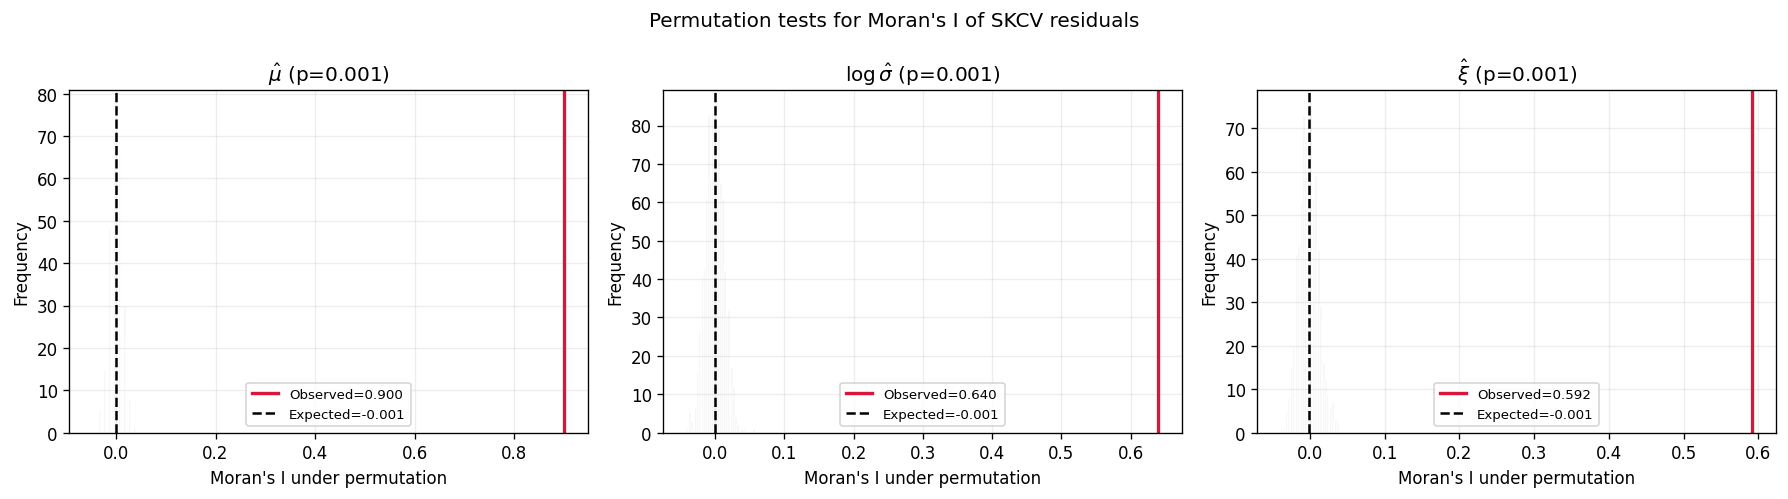

In [17]:
def morans_i_knn(xy, values, k=8, permutations=999, seed=111):
    xy = np.asarray(xy, dtype=float)
    z = np.asarray(values, dtype=float)
    z = z - z.mean()
    nn = NearestNeighbors(n_neighbors=k + 1).fit(xy)
    _, indices = nn.kneighbors(xy)
    neighbors = indices[:, 1:]
    rows = np.repeat(np.arange(len(xy)), k)
    cols = neighbors.ravel()
    data = np.full(len(rows), 1.0 / k)
    W = csr_matrix((data, (rows, cols)), shape=(len(xy), len(xy)))
    s0 = float(W.sum())
    denom = float(z @ z)
    observed = float((len(z) / s0) * (z @ (W @ z)) / denom)
    expected = -1.0 / (len(z) - 1)

    rng = np.random.default_rng(seed)
    permuted = np.empty(permutations)
    for i in range(permutations):
        zp = rng.permutation(z)
        permuted[i] = (len(z) / s0) * (zp @ (W @ zp)) / (zp @ zp)
    p_value = (1 + np.sum(np.abs(permuted - expected) >= abs(observed - expected))) / (
        permutations + 1
    )
    return observed, expected, p_value, permuted


moran_rows = []
moran_permutations = {}
for order, target in enumerate(TARGETS):
    part = oof_residuals.query("target == @target").sort_values("row_index")
    observed, expected, p_value, permuted = morans_i_knn(
        part[["x_km", "y_km"]].to_numpy(),
        part["residual"].to_numpy(),
        k=8,
        permutations=MORAN_PERMUTATIONS,
        seed=RANDOM_STATE + order,
    )
    moran_rows.append({
        "target": target,
        "radius_km": selected_radius[target],
        "Moran_I": observed,
        "expected_I": expected,
        "permutation_p": p_value,
        "k_neighbors": 8,
        "n_permutations": MORAN_PERMUTATIONS,
    })
    moran_permutations[target] = permuted
moran_results = pd.DataFrame(moran_rows)
moran_results.to_csv(
    TABLE_DIR / "spatial_validation_residual_morans_i.csv",
    index=False,
    encoding="utf-8-sig",
)
display(moran_results.round(5))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, target in zip(axes, TARGETS):
    row = moran_results.query("target == @target").iloc[0]
    permuted = moran_permutations[target]
    ax.hist(permuted, bins=35, color="lightgray", edgecolor="white")
    ax.axvline(row["Moran_I"], color="crimson", lw=2, label=f"Observed={row['Moran_I']:.3f}")
    ax.axvline(row["expected_I"], color="black", ls="--", label=f"Expected={row['expected_I']:.3f}")
    ax.set(
        title=f"{TARGET_LABELS[target]} (p={row['permutation_p']:.3f})",
        xlabel="Moran's I under permutation",
        ylabel="Frequency",
    )
    ax.legend(fontsize=8)
fig.suptitle("Permutation tests for Moran's I of SKCV residuals")
fig.tight_layout()
fig.savefig(FIG_DIR / "spatial_validation_11_morans_i.png", bbox_inches="tight")
plt.show()

## 10. 報告時的判斷順序

1. **K=5 的用途**：建立具有區域解釋的 testing folds；不是由 Valavi 指定。
2. **Variogram range 的用途**：產生具有 spatial autocorrelation 依據的候選距離。
3. **SKCV 的用途**：估計 training measurement 距離 test location 至少
   \(r_\delta\) 時的預測誤差。
4. **SKCV-RLO 的用途**：判斷 SKCV 誤差上升是否只因 training data 變少。
5. **Report radius**：本 notebook 使用「第一個不小於 fitted effective range 的 10 km
   候選值」作為可重現的報告點；完整 distance curve 仍必須一起報告。
6. **Residual SAC**：若仍顯著，依序檢查 buffer、kernel、遺漏 predictor、
   anisotropy 與 nonstationarity；不能直接斷言只有 buffer 太短。

### 重要限制

- Variogram 使用 isotropic、stationary 假設；若 empirical variogram 明顯不穩定，
  effective range 應視為候選尺度，不是精確真值。
- 目前採 exact GP 的 800-point base pool，因此結果代表此固定計算預算下的比較。
- 若同一套 SKCV 同時選 kernel 又宣稱是最終無偏泛化誤差，嚴格做法應使用 nested spatial CV。
  本 notebook 將 AIC、kernel comparison 與 distance sensitivity 分開輸出，避免把單一指標當成唯一證明。